# Data Engineering and Exploratory Data Analysis

This project demonstrates a basic data engineering workflow using a PostgreSQL database hosted on Neon. Synthetic employee data is generated using Faker, stored in the database, retrieved using Python, and analyzed using Pandas.

In [35]:
from pathlib import Path
import sys

src_folder = Path.cwd().parent / "src"
sys.path.insert(0, str(src_folder))

In [10]:
import pandas as pd
from database import connect_to_database


In [9]:
connection = connect_to_database()

print("Connected to Neon successfully!")

Connected to Neon successfully!


In [11]:
query = """
SELECT *
FROM employees
ORDER BY employee_id;
"""

In [12]:
df = pd.read_sql(query, connection)

print("Data loaded successfully!")

C:\Users\aarya\AppData\Local\Temp\ipykernel_10520\891713503.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Data loaded successfully!


In [13]:
connection.close()

print("Database connection closed.")

Database connection closed.


In [14]:
df.head()

,employee_id,name,position,start_date,salary
0,1,NaN,Database Administrator,2019-01-31,181103.0
1,2,NaN,IT Support Specialist,2015-06-26,177897.0
2,3,NaN,Network Administrator,2017-03-16,121123.0
3,4,NaN,IT Support Specialist,2015-03-20,196678.0
4,5,NaN,Network Administrator,2018-03-21,152555.0


In [15]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 101
Columns: 5


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   employee_id  101 non-null    int64  
 1   name         96 non-null     str    
 2   position     96 non-null     str    
 3   start_date   96 non-null     object 
 4   salary       96 non-null     float64
dtypes: float64(1), int64(1), object(1), str(2)
memory usage: 4.1+ KB


In [17]:
df.describe()

,employee_id,salary
count,101.000000,96.000000
mean,51.000000,134249.000000
std,29.300171,38912.302367
min,1.000000,60178.000000
25%,26.000000,103298.750000
50%,51.000000,132857.000000
75%,76.000000,169020.500000
max,101.000000,199457.000000


In [18]:
df.isnull().sum()

employee_id    0
name           5
position       5
start_date     5
salary         5
dtype: int64

## Initial Data Exploration

The employee data was retrieved from the Neon PostgreSQL database and loaded into a Pandas DataFrame. The `head()` function was used to display the records, while `info()` was used to check the structure and data types. The `describe()` function is used for summary statistics for numerical columns. And `isnull().sum()` was used to identify missing values in the dataset.

## Data Cleaning

In [19]:
df_clean = df.copy()

In [21]:
df_clean.isnull().sum()
print("Total missing values:", df_clean.isnull().sum().sum())

Total missing values: 20


In [22]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [ ]:
# check the position value
df_clean["position"].value_counts(dropna=False)

position
Network Administrator     14
Network Engineer          12
DevOps Engineer           12
Data Analyst              11
Software Developer         8
Cloud Engineer             8
Systems Administrator      8
IT Support Specialist      7
Cybersecurity Analyst      7
Database Administrator     6
NaN                        5
 software developer        1
DATA ANALYST               1
network administrator      1
Name: count, dtype: int64

In [24]:
#Clean text ccolumn

df_clean["name"] = df_clean["name"].str.strip()
df_clean["position"] = df_clean["position"].str.strip()

In [ ]:
#Standardize the position column to title case
position_corrections = {
    "software developer": "Software Developer",
    "Software developer": "Software Developer",
    "data analyst": "Data Analyst",
    "Data analyst": "Data Analyst",
    "network engineer": "Network Engineer",
    "Network engineer": "Network Engineer",
    "cloud engineer": "Cloud Engineer",
    "cybersecurity analyst": "Cybersecurity Analyst",
    "DATA ANALYST": "Data Analyst",
    "network administrator": "Network Administrator",
    "Network Administrator": "Network Administrator",
}

df_clean["position"] = df_clean["position"].replace(position_corrections)
df_clean["position"].value_counts(dropna=False)

position
Network Administrator     14
Network Engineer          12
DevOps Engineer           12
Data Analyst              11
Software Developer         9
Cloud Engineer             8
Systems Administrator      8
IT Support Specialist      7
Cybersecurity Analyst      7
Database Administrator     6
NaN                        5
DATA ANALYST               1
network administrator      1
Name: count, dtype: int64

In [28]:
#handle missing values
df_clean = df_clean.dropna(
    subset=["name", "position", "start_date", "salary"]
)

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))

Rows before cleaning: 101
Rows after cleaning: 81


In [30]:
#Remove duplicate records
df_clean = df_clean.drop_duplicates()

print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

Duplicate rows after cleaning: 0


In [31]:
#Display clean data
df_clean.head()

,employee_id,name,position,start_date,salary
20,21,Jordan Peck,Software Developer,2022-08-22,106273.0
21,22,Samantha Barker,DATA ANALYST,2020-06-01,102953.0
22,23,Andrew Nolan,network administrator,2016-05-15,131459.0
23,24,Sean Friedman,Network Administrator,2019-02-01,162468.0
24,25,William Decker,Network Engineer,2018-06-13,110873.0


In [32]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 20 to 100
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   employee_id  81 non-null     int64  
 1   name         81 non-null     str    
 2   position     81 non-null     str    
 3   start_date   81 non-null     object 
 4   salary       81 non-null     float64
dtypes: float64(1), int64(1), object(1), str(2)
memory usage: 3.3+ KB


In [33]:
df_clean.isnull().sum()

employee_id    0
name           0
position       0
start_date     0
salary         0
dtype: int64

## Data Cleaning

The raw employee dataset contained missing values, inconsistent text formatting, and duplicate records. A copy of the original dataset was created before cleaning. Missing values in important employee fields were removed, unnecessary spaces were removed from text fields and inconsistent position names were standardized. Check for the duplicate values but there was no duplicate values. The cleaned dataset was then checked again to confirm that the main data quality issues had been addressed.

In [5]:
import pandas as pd
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from database import connect_to_database
from data_cleaning import clean_employee_data

In [6]:
connection = connect_to_database()

query = """
SELECT *
FROM employees
ORDER BY employee_id;
"""

df = pd.read_sql(query, connection)

connection.close()

C:\Users\aarya\AppData\Local\Temp\ipykernel_20012\872443654.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [7]:
print(df.shape)
df.head()

(101, 5)


,employee_id,name,position,start_date,salary
0,1,NaN,Database Administrator,2019-01-31,181103.0
1,2,NaN,IT Support Specialist,2015-06-26,177897.0
2,3,NaN,Network Administrator,2017-03-16,121123.0
3,4,NaN,IT Support Specialist,2015-03-20,196678.0
4,5,NaN,Network Administrator,2018-03-21,152555.0


In [8]:
df_clean = clean_employee_data(df)

In [9]:
df_clean.isnull().sum()
df_clean.head()

,employee_id,name,position,start_date,salary
20,21,Jordan Peck,Software Developer,2022-08-22,106273.0
21,22,Samantha Barker,DATA ANALYST,2020-06-01,102953.0
22,23,Andrew Nolan,network administrator,2016-05-15,131459.0
23,24,Sean Friedman,Network Administrator,2019-02-01,162468.0
24,25,William Decker,Network Engineer,2018-06-13,110873.0


In [10]:
df_clean["start_date"] = pd.to_datetime(df_clean["start_date"])

In [11]:
df_clean["start_year"] = df_clean["start_date"].dt.year

In [12]:
df_clean.head()

,employee_id,name,position,start_date,salary,start_year
20,21,Jordan Peck,Software Developer,2022-08-22,106273.0,2022
21,22,Samantha Barker,DATA ANALYST,2020-06-01,102953.0,2020
22,23,Andrew Nolan,network administrator,2016-05-15,131459.0,2016
23,24,Sean Friedman,Network Administrator,2019-02-01,162468.0,2019
24,25,William Decker,Network Engineer,2018-06-13,110873.0,2018


## Data Transformation

The `start_date` column was converted to a Pandas datetime format. 
The year was then extracted from the start date to create a new 
`start_year` column. This makes it easier to analyze employee salary 
patterns by the year.

In [13]:
from datetime import datetime

current_year = datetime.now().year

df_clean["years_of_service"] = (
    current_year - df_clean["start_year"]
)

In [14]:
df_clean[
    ["name", "start_date", "start_year", "years_of_service"]
].head()

,name,start_date,start_year,years_of_service
20,Jordan Peck,2022-08-22,2022,4
21,Samantha Barker,2020-06-01,2020,6
22,Andrew Nolan,2016-05-15,2016,10
23,Sean Friedman,2019-02-01,2019,7
24,William Decker,2018-06-13,2018,8


## Feature Engineering

New features were created from the existing employee data. 
`years_of_service` represents the approximate number of years an employee 
has worked since their start year.

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
scaler = MinMaxScaler()

In [17]:
df_clean["salary_scaled"] = scaler.fit_transform(
    df_clean[["salary"]]
)

In [18]:
df_clean[
    ["salary", "salary_scaled"]
].head(10)

,salary,salary_scaled
20,106273.0,0.330954
21,102953.0,0.307117
22,131459.0,0.511786
23,162468.0,0.734425
24,110873.0,0.363982
25,109207.0,0.352020
26,103414.0,0.310427
27,127396.0,0.482614
28,136160.0,0.545538
29,168848.0,0.780232


## Feature Scaling

Min-Max Scaling was applied to the salary column using Scikit-learn. 
The transformation converts salary values to a range between 0 and 1. 
The original salary column was retained so that actual salary values can 
still be used for interpretation and visualization.

In [19]:
df_clean.head()

,employee_id,name,position,start_date,salary,start_year,years_of_service,salary_scaled
20,21,Jordan Peck,Software Developer,2022-08-22,106273.0,2022,4,0.330954
21,22,Samantha Barker,DATA ANALYST,2020-06-01,102953.0,2020,6,0.307117
22,23,Andrew Nolan,network administrator,2016-05-15,131459.0,2016,10,0.511786
23,24,Sean Friedman,Network Administrator,2019-02-01,162468.0,2019,7,0.734425
24,25,William Decker,Network Engineer,2018-06-13,110873.0,2018,8,0.363982


In [20]:
average_salary = df_clean["salary"].mean()

print("Average Salary:", round(average_salary, 2))

Average Salary: 133661.19


In [21]:
salary_by_position = (
    df_clean.groupby("position")["salary"]
    .mean()
    .sort_values(ascending=False)
)

salary_by_position

position
Cloud Engineer            157862.285714
IT Support Specialist     149399.500000
Network Administrator     144248.555556
Systems Administrator     141624.750000
Network Engineer          132764.200000
network administrator     131459.000000
DevOps Engineer           131183.454545
Cybersecurity Analyst     129714.571429
Data Analyst              128227.363636
Database Administrator    115882.800000
Software Developer        112814.000000
DATA ANALYST              102953.000000
Name: salary, dtype: float64

In [22]:
df_clean["position"].value_counts()

position
Data Analyst              11
DevOps Engineer           11
Network Engineer          10
Network Administrator      9
Systems Administrator      8
Software Developer         7
Cloud Engineer             7
Cybersecurity Analyst      7
Database Administrator     5
IT Support Specialist      4
DATA ANALYST               1
network administrator      1
Name: count, dtype: int64

In [23]:
df_clean["start_year"].value_counts().sort_index()

start_year
2015     9
2016     2
2017    11
2018     8
2019     9
2020    14
2021     7
2022     8
2023     8
2024     5
Name: count, dtype: int64

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed on the cleaned employee
dataset to understand its main characteristics. The analysis checked
average salary, salary by job position, the number of employees in each
position, and employee start years.



In [24]:
import matplotlib.pyplot as plt

In [25]:
salary_position_year = (
    df_clean
    .groupby(["start_year", "position"])["salary"]
    .mean()
    .unstack()
)

salary_position_year

position,Cloud Engineer,Cybersecurity Analyst,DATA ANALYST,Data Analyst,Database Administrator,DevOps Engineer,IT Support Specialist,Network Administrator,Network Engineer,Software Developer,Systems Administrator,network administrator
start_year,,,,,,,,,,,,
2015,NaN,127804.5,NaN,161657.0,NaN,159248.000000,NaN,NaN,129468.666667,138644.5,NaN,NaN
2016,NaN,NaN,NaN,NaN,NaN,173059.000000,NaN,NaN,NaN,NaN,NaN,131459.0
2017,168843.0,86865.0,NaN,137315.0,NaN,184253.000000,NaN,199457.0,147261.666667,NaN,163566.000000,NaN
2018,NaN,149964.0,NaN,NaN,NaN,72742.000000,NaN,169859.0,128329.000000,NaN,148159.000000,NaN
2019,144991.5,NaN,NaN,138895.0,74923.0,NaN,NaN,162468.0,NaN,86989.0,NaN,NaN
2020,NaN,NaN,102953.0,155607.5,144766.0,153549.666667,NaN,155412.0,148991.000000,116079.0,122780.666667,NaN
2021,144135.0,NaN,NaN,110566.0,NaN,77193.000000,98998.0,133592.5,NaN,NaN,NaN,NaN
2022,189097.0,171453.0,NaN,61372.0,NaN,NaN,NaN,90694.0,91802.000000,106273.0,119702.000000,NaN
2023,NaN,94147.0,NaN,104064.0,126174.0,94284.000000,166200.0,NaN,NaN,NaN,185070.000000,NaN


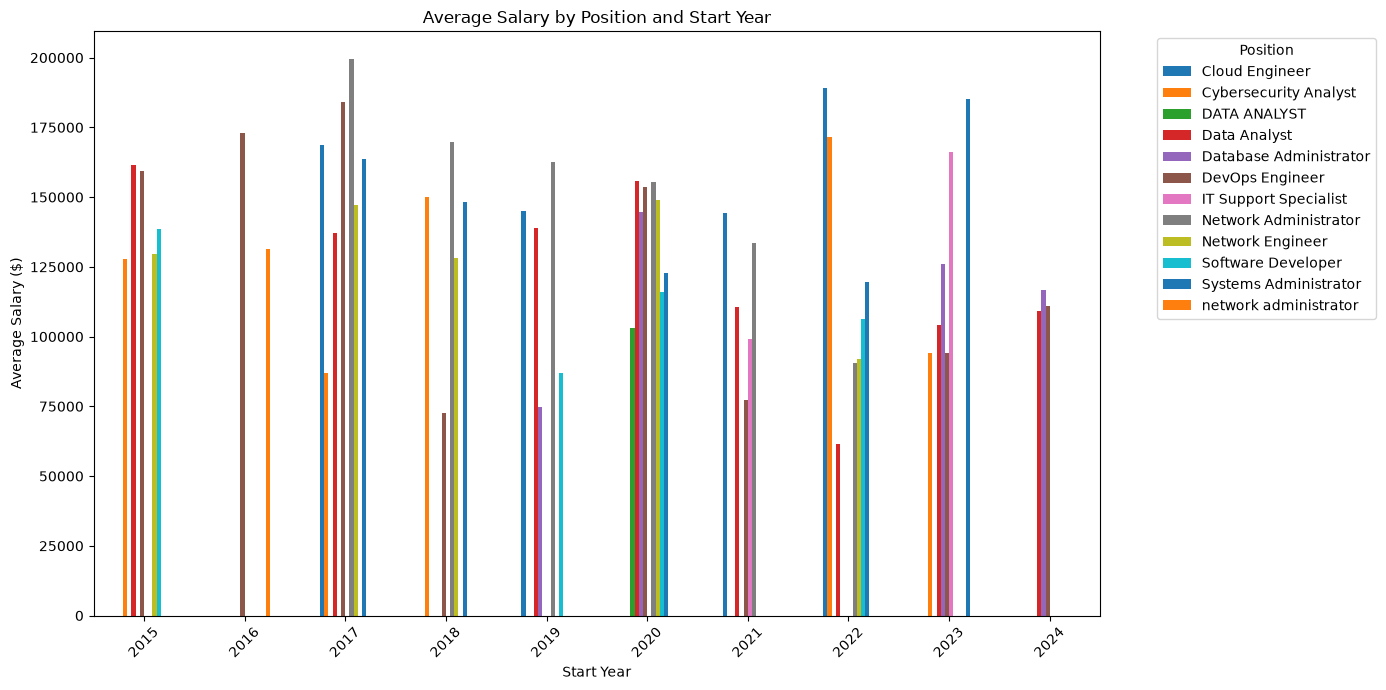

In [26]:
salary_position_year.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Average Salary by Position and Start Year")
plt.xlabel("Start Year")
plt.ylabel("Average Salary ($)")
plt.xticks(rotation=45)
plt.legend(
    title="Position",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Average Salary by Position and Start Year

The grouped bar chart compares the average salary of different IT job
positions across employee start years. It allows salary differences between
positions and years to be visually compared.


In [27]:
department_data = {
    "department": [
        "Software Development",
        "Data & Analytics",
        "Infrastructure",
        "Cybersecurity",
        "IT Operations"
    ],
    "location": [
        "Toronto",
        "Toronto",
        "Kitchener",
        "Ottawa",
        "Waterloo"
    ],
    "annual_budget": [
        2500000,
        1800000,
        1500000,
        2200000,
        1700000
    ]
}

departments_df = pd.DataFrame(department_data)

departments_df

,department,location,annual_budget
0,Software Development,Toronto,2500000
1,Data & Analytics,Toronto,1800000
2,Infrastructure,Kitchener,1500000
3,Cybersecurity,Ottawa,2200000
4,IT Operations,Waterloo,1700000


## Mapping Employee Positions to Departments

Each IT position is assigned to an appropriate department. This creates a common
`department` column that can be used to merge the employee dataset with the
department dataset.

In [28]:
position_department = {
    "Software Developer": "Software Development",
    "Data Analyst": "Data & Analytics",
    "Database Administrator": "Data & Analytics",
    "Network Administrator": "Infrastructure",
    "Network Engineer": "Infrastructure",
    "Systems Administrator": "Infrastructure",
    "Cloud Engineer": "Infrastructure",
    "Cybersecurity Analyst": "Cybersecurity",
    "DevOps Engineer": "IT Operations",
    "IT Support Specialist": "IT Operations"
}

In [29]:
df_clean["department"] = df_clean["position"].map(position_department)

In [30]:
df_clean[["position", "department"]].head(10)

,position,department
20,Software Developer,Software Development
21,DATA ANALYST,NaN
22,network administrator,NaN
23,Network Administrator,Infrastructure
24,Network Engineer,Infrastructure
25,Data Analyst,Data & Analytics
26,Network Administrator,Infrastructure
27,Software Developer,Software Development
28,Systems Administrator,Infrastructure
29,Cloud Engineer,Infrastructure


In [33]:
df_clean["department"].isnull().sum()

np.int64(2)